In [1]:
import numpy as np 
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt

# Student's t distribution vs normal distribution

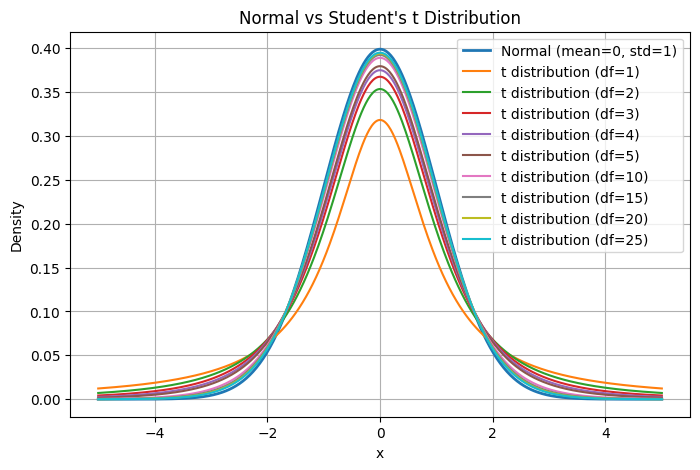

In [2]:
x = np.linspace(-5, 5, 500)

normal_pdf = st.norm.pdf(x, loc=0, scale=1)

dfs = [1, 2, 3, 4, 5, 10, 15, 20, 25]

plt.figure(figsize=(8,5))

plt.plot(x, normal_pdf, label="Normal (mean=0, std=1)", linewidth=2)

for df in dfs:
    plt.plot(x, st.t.pdf(x, df), label=f"t distribution (df={df})")

plt.title("Normal vs Student's t Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

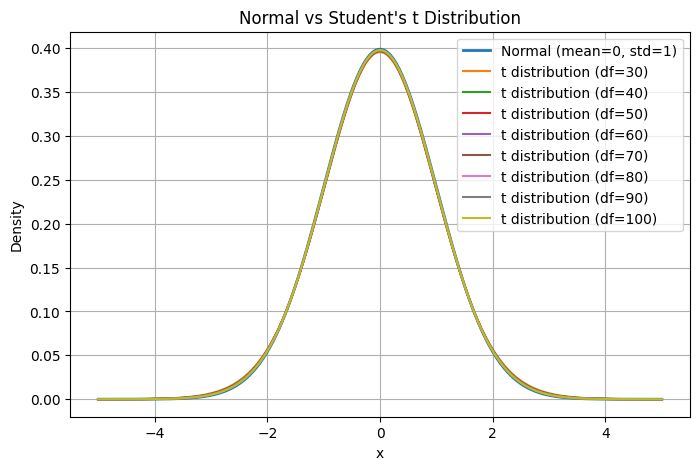

In [3]:
x = np.linspace(-5, 5, 500)

normal_pdf = st.norm.pdf(x, loc=0, scale=1)

dfs = [30, 40, 50, 60, 70, 80, 90, 100]

plt.figure(figsize=(8,5))

plt.plot(x, normal_pdf, label="Normal (mean=0, std=1)", linewidth=2)

for df in dfs:
    plt.plot(x, st.t.pdf(x, df), label=f"t distribution (df={df})")

plt.title("Normal vs Student's t Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

When we have larger df, it means we have less uncertainty and student's t distribution approaches to the normal distribution. However, note that it is always more accurate to use the t-distribution when the population standard deviation is unknown.


# Hypothesis Testing

Null Hypothesis $H_0: \mu = \mu_0$

Alternative Hypothesis $H_1: \mu \neq \mu_0$ (two-tailed) or $H_1: \mu < \mu_0$ (left-tailed) or $H_1: \mu > \mu_0$ (right-tailed)

### $z$-test

#### Example
Boys of a certain age are known to have a mean weight of $\mu = 85$ pounds. A complaint is made that the boys living in a municipal children's home are underfed. As one bit of evidence, $n=25$ boys (of the same age) are weighed and found to have a mean weight of 
$\bar{x} = 80.94$ pounds. It is known that the population standard deviation $\sigma$ is 11.6 pounds (the unrealistic part of this example!). Based on the available data, what should be concluded concerning the complaint?

Null Hypothesis $H_0: \mu = 85 $

Alternative Hypothesis $H_1: \mu < 85$

Population variance is known, so we use $z$-test and the hypothesis test is left-tailed.

$$z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}} $$

In [4]:
z = (80.94 - 85) / (11.6 / np.sqrt(25))
print(z)

-1.750000000000001


In [5]:
#for alpha = 0.05 significance level let find critical region from z-table
alpha = 0.05
critical_point = st.norm.ppf(alpha)
critical_point

-1.6448536269514729

In [6]:
# so critical region at alpha = 0.05 is z < -1.65
z < critical_point

True

Therefore, we reject the null hypothesis.

In [7]:
# Try to draw same conclusion using p-value approach
p = st.norm.cdf(z)
print(p)
print(p < alpha)

0.04005915686381699
True


So, we reject $H_0$ for 0.05 significance level by $z$-test.

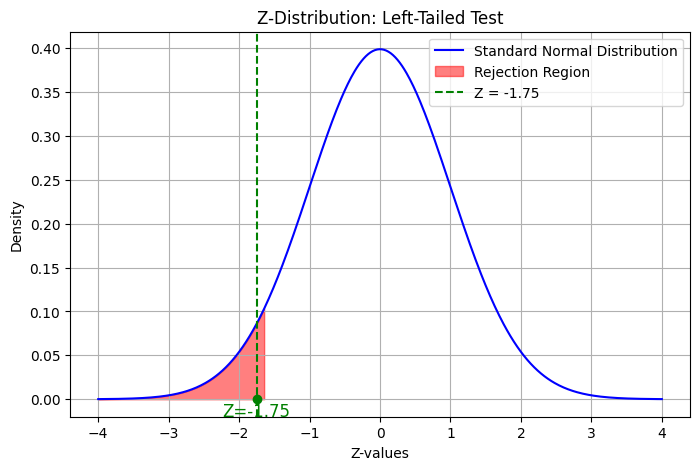

In [8]:
# generate x, y values from normal distn
x = np.linspace(-4, 4, 500)
y = st.norm.pdf(x, 0, 1)  # Standard normal PDF (mean=0, std=1)


plt.figure(figsize=(8, 5))
plt.plot(x, y, label="Standard Normal Distribution", color="blue")

# critical region (left-tailed test)
x_critical = np.linspace(-4, critical_point, 100)
plt.fill_between(x_critical, st.norm.pdf(x_critical, 0, 1), color='red', alpha=0.5, label='Rejection Region')

# Mark the z-value
plt.axvline(z, color='green', linestyle='--', label=f'Z = {round(z,2)}')
plt.scatter([z], [0], color='green', zorder=3)  # Mark the Z-value on the x-axis
plt.text(z, -0.02, f'Z={round(z,2)}', color='green', fontsize=12, ha='center')

plt.title('Z-Distribution: Left-Tailed Test')
plt.xlabel('Z-values')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()


### $t$-test

It is assumed that the mean systolic blood pressure is $\mu = 120$ mm Hg. In the Honolulu Heart Study, a sample of $n=100$ people had an average systolic blood pressure of 130.1 mm Hg with a standard deviation of 21.21 mm Hg. Is the group significantly different (with respect to systolic blood pressure!) from the regular population?

Null Hypothesis $H_0: \mu = 120$

Alternative Hypothesis $H_1: \mu \neq 120$

Population variance is unknown, so we use $t$-test and it will be two-tailed.

$$ t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$
which follows $t$-distribution with $n-1$ degrees of freedom.



In [9]:
t = (130.1 - 120) / (21.21 / np.sqrt(100))
t

4.761904761904759

In [10]:
#for alpha = 0.05 significance level and n-1 = 99 degrees of freedom
# let find critical region from t-table
alpha = 0.05
df = 99
#Use two-tailed test
critical_point = st.t.ppf(alpha/2, df)
critical_point

-1.9842169515086832

In [11]:
t < critical_point or t > np.abs(critical_point)

True

In [12]:
# Try to draw same conclusion using p-value approach
p = st.t.sf(t, df)
print(p)
print(p < alpha/2)

3.2813509086043083e-06
True


So, we reject $H_0$ for 0.05 significance level by $t$-test.

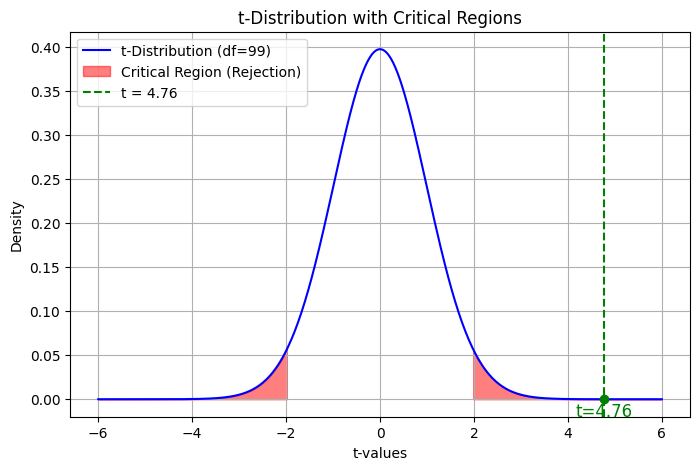

In [13]:

x = np.linspace(-6, 6, 500)
y = st.t.pdf(x, df)


plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f't-Distribution (df={df})', color='blue')

x_critical_right = np.linspace(-critical_point, 6, 100)
x_critical_left = np.linspace(-6, critical_point, 100)
plt.fill_between(x_critical_right, st.t.pdf(x_critical_right, df), color='red', alpha=0.5, label='Critical Region (Rejection)')
plt.fill_between(x_critical_left, st.t.pdf(x_critical_left, df), color='red', alpha=0.5)

plt.axvline(t, color='green', linestyle='--', label=f't = {round(t,2)}')

plt.scatter([t], [0], color='green', zorder=3)  # Mark the t-value
plt.text(t, -0.02, f't={round(t,2)}', color='green', fontsize=12, ha='center')

plt.title('t-Distribution with Critical Regions')
plt.xlabel('t-values')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()


# Tests of the Equality of Two Means

### When Population Variances Are Equal - Pooled $t$-test

We have two independent samples from two normal distributions with equal variances $\sigma_X^2 = \sigma_Y^2 = \sigma^2$.

sample $X$ $\rightarrow$ $n$: the number of observations, $S_X^2$: sample variance

sample $Y$ $\rightarrow$ $m$: the number of observations, $S_Y^2$: sample variance

degrees of freedom $df = n + m - 2$

$S_P^2$ is the pooled sample variance such that $ S_P^2 = \frac{(n-1)S_X^2 + (m-1)S_Y^2}{n+m-2} $.

Null Hypothesis $H_0: \mu_X = \mu_Y$

Alternative Hypothesis $H_1: \mu_X \neq \mu_Y$ or $H_1: \mu_X < \mu_Y$ or $H_1: \mu_X > \mu_Y$

Then, the test statistic
$$ T =  \frac{(\bar{X}-\bar{Y}) - (\mu_X - \mu_Y)}{S_P \sqrt{\frac{1}{n} + \frac{1}{m}}} $$



#### Example

A psychologist was interested in exploring whether or not male and female college students have different driving behaviors. There were several ways that she could quantify driving behaviors. She opted to focus on the fastest speed ever driven by an individual. Therefore, the particular statistical question she framed was as follows:
- Is the mean fastest speed driven by male college students different than the mean fastest speed driven by female college students?

She conducted a survey of a random $n=34$ male college students and a random $m=29$ female college students. Here is a descriptive summary of the results of her survey:

$$ \text{Males: } \bar{X} = 105.5, S_X = 20.1, n=34  $$

$$ \text{Females: } \bar{Y} = 90.9, S_Y = 12.2, m=29  $$

Is there sufficient evidence at the $\alpha = 0.05$ significance level to conclude that the mean fastest speed driven by male college students differs from the mean fastest speed driven by female college students?

In [14]:
X_bar = 105.5
S_X = 20.1
n = 34
Y_bar = 90.9
S_Y = 12.2
m = 29

S_P = np.sqrt(((n-1)*S_X**2 + (m-1)*S_Y**2) / (n+m-2))
print("pooled sample variance: ", S_P)

T = (X_bar - Y_bar) / (S_P * np.sqrt((1/n)+(1/m)))
print("test statistic: T = ", T)


pooled sample variance:  16.93761455711063
test statistic: T =  3.4101131776909535


In [15]:
# critical value approach
df = n + m - 2
alpha = 0.05
critical_value = st.t.ppf(alpha/2, df)
print(critical_value)

-1.9996235849949395


In [16]:
T > -critical_value or T < critical_value

True

In [17]:
# p-value 
p = st.t.sf(T, df)
print(p)
print(p < alpha/2)

0.0005783712704484324
True


We reject null hypothesis.

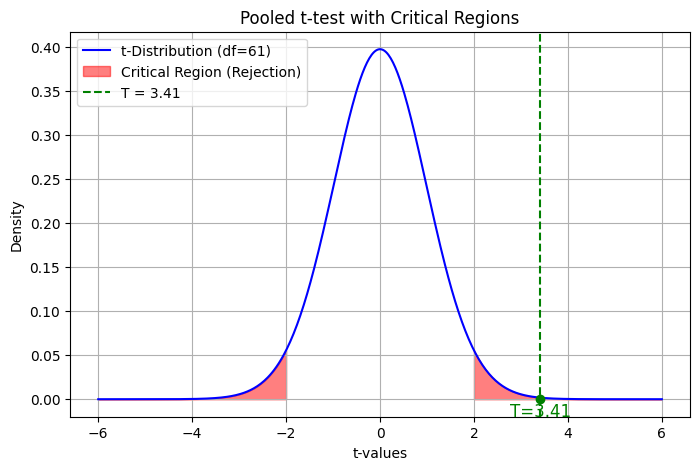

In [18]:
x = np.linspace(-6, 6, 500)
y = st.t.pdf(x, df)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f't-Distribution (df={df})', color='blue')

x_critical_right = np.linspace(-critical_value, 6, 100)
x_critical_left = np.linspace(-6, critical_value, 100)
plt.fill_between(x_critical_right, st.t.pdf(x_critical_right, df), color='red', alpha=0.5, label='Critical Region (Rejection)')
plt.fill_between(x_critical_left, st.t.pdf(x_critical_left, df), color='red', alpha=0.5)

plt.axvline(T, color='green', linestyle='--', label=f'T = {round(T,2)}')

plt.scatter([T], [0], color='green', zorder=3) 
plt.text(T, -0.02, f'T={round(T,2)}', color='green', fontsize=12, ha='center')

plt.title('Pooled t-test with Critical Regions')
plt.xlabel('t-values')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()

### When Population Variances Are not Equal - Welch's $t$-test

We have two independent samples from two normal distributions with variances $\sigma_X^2$, $\sigma_Y^2$.

Null Hypothesis $H_0: \mu_X = \mu_Y$

Alternative Hypothesis $H_1: \mu_X \neq \mu_Y$ or $H_1: \mu_X < \mu_Y$ or $H_1: \mu_X > \mu_Y$

Then, the test statistic
$$ T =  \frac{(\bar{X}-\bar{Y}) - (\mu_X - \mu_Y)}{\sqrt{\frac{S_X^2}{n} + \frac{S_Y^2}{m}}} $$

Degrees of freedom r (If r doesn't equal an integer, as it usually doesn't, then we take the integer portion of r.)
$$r = \frac{(\frac{S_X^2}{n} + \frac{S_Y^2}{m})^2}{\frac{(S_X^2 / n)^2}{n-1} + \frac{(S_Y^2 / m)^2}{m-1}}  $$


In [19]:
# Continue with the same example

X_bar = 105.5
S_X = 20.1
n = 34
Y_bar = 90.9
S_Y = 12.2
m = 29


T = (X_bar - Y_bar) / (np.sqrt((S_X**2/n)+(S_Y**2/m)))
print("test statistic: T = ", T)

r = ((S_X**2 / n) + (S_Y**2 / m))**2 / (((S_X**2/n)**2)/(n-1) + ((S_Y**2/m)**2)/(m-1))
r = int(r)
print("degrees of freedom: r = ", r)

test statistic: T =  3.539452614638691
degrees of freedom: r =  55


In [20]:
# critical value approach
alpha = 0.05
critical_value = st.t.ppf(alpha/2, r)
print(critical_value)

-2.0040447832891464


In [21]:
# p-value 
p = st.t.sf(T, r)
print(p)
print(2 * p < alpha)

0.0004121063457861748
True


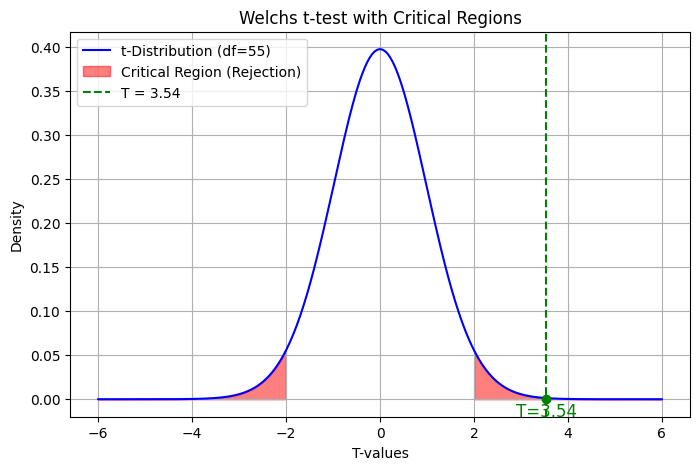

In [22]:
x = np.linspace(-6, 6, 500)
y = st.t.pdf(x, r) 

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f't-Distribution (df={r})', color='blue')

x_critical_right = np.linspace(-critical_value, 6, 100)
x_critical_left = np.linspace(-6, critical_value, 100)
plt.fill_between(x_critical_right, st.t.pdf(x_critical_right, r), color='red', alpha=0.5, label='Critical Region (Rejection)')
plt.fill_between(x_critical_left, st.t.pdf(x_critical_left, r), color='red', alpha=0.5)

plt.axvline(T, color='green', linestyle='--', label=f'T = {round(T,2)}')

plt.scatter([T], [0], color='green', zorder=3)
plt.text(T, -0.02, f'T={round(T,2)}', color='green', fontsize=12, ha='center')

plt.title('Welchs t-test with Critical Regions')
plt.xlabel('T-values')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()

## Tests for Variances

#### One Variance
A random sample of size $n$ from a normal population with (unknown) mean $\mu$ and variance $\sigma^2$, sample variance S^2 

Null Hypothesis $H_0: \sigma^2 = \sigma_0^2$

Alternative Hypothesis $H_1: \sigma^2 \neq \sigma_0^2$ or $H_1: \sigma^2 < \sigma_0^2$ or $H_1: \sigma^2 > \sigma_0^2$

Then, test statistic (Chi-square)  is:
$$ \mathcal{X}^2 = \frac{(n-1) S^2}{\sigma_0^2}  $$

#### Example
A manufacturer of hard safety hats for construction workers is concerned about the mean and the variation of the forces its helmets transmits to wearers when subjected to an external force. The manufacturer has designed the helmets so that the mean force transmitted by the helmets to the workers is 800 pounds (or less) with a standard deviation to be less than 40 pounds. Tests were run on a random sample of $n = 40$ helmets, and the sample mean and sample standard deviation were found to be 825 pounds and 48.5 pounds, respectively. Do the data provide sufficient evidence, at the $\alpha = 0.05$ significance level, to conclude that the population standard deviation exceeds 40 pounds?

Let define null and alternative hypotheses:
- Null Hypothesis $H_0: \sigma^2 = 40^2$
- Alternative Hypothesis $H_1: \sigma^2 > 40^2$

So, it will be right-tailed test.

In [23]:
sigma = 40
S = 48.5
n = 40
# compute test statistic
X_2 = ((n-1) * (S**2)) / (sigma**2)
X_2

57.33609375

In [24]:
df = n-1
alpha = 0.05
critical_value = st.chi2.isf(alpha, df)
critical_value

54.57222775894174

In [25]:
X_2 > critical_value

True

In [26]:
# p-value 
p = st.chi2.sf(X_2, df)
print(p)
print(p < alpha)

0.02928367514477533
True


We reject $H_0$.

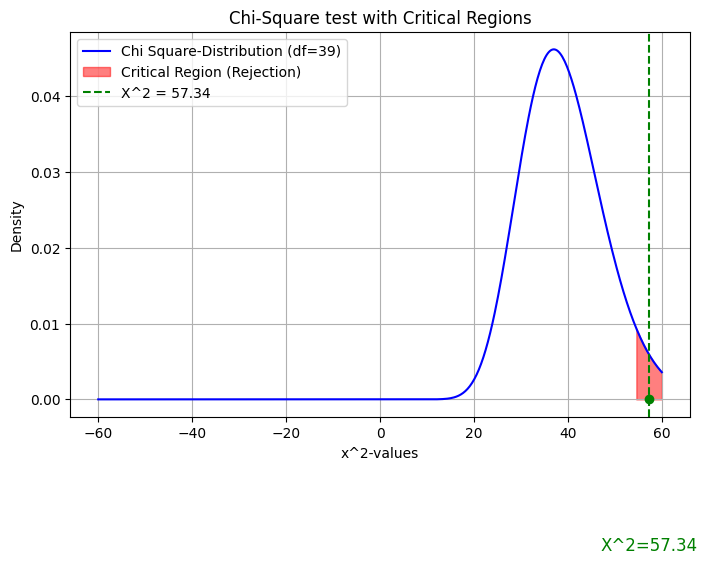

In [27]:
x = np.linspace(-60, 60, 500)
y = st.chi2.pdf(x, df) 

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f'Chi Square-Distribution (df={df})', color='blue')

x_critical_right = np.linspace(critical_value, 60, 100)
plt.fill_between(x_critical_right, st.chi2.pdf(x_critical_right, df), color='red', alpha=0.5, label='Critical Region (Rejection)')

plt.axvline(X_2, color='green', linestyle='--', label=f'X^2 = {round(X_2,2)}')

plt.scatter([X_2], [0], color='green', zorder=3)
plt.text(X_2, -0.02, f'X^2={round(X_2,2)}', color='green', fontsize=12, ha='center')

plt.title('Chi-Square test with Critical Regions')
plt.xlabel('x^2-values')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()

#### Two Variance
Two random sample from normal distribution
- $X_1, X_2, ..., X_n \rightarrow$ $n$: sample size, $\mu_X$: mean, $\sigma_X^2$: variance
- $Y_1, Y_2, ..., Y_m \rightarrow$ $m$: sample size, $\mu_Y$: mean, $\sigma_Y^2$: variance

Null Hypothesis $H_0: \sigma_X^2 = \sigma_Y^2$

Alternative Hypothesis $H_1: \sigma_X^2 \neq \sigma_Y^2$ or $H_1: \sigma_X^2 < \sigma_Y^2$ or $H_1: \sigma_X^2 > \sigma_Y^2$

Then, test statistic ($F$-test)  is:
$$ F = \frac{S_X^2}{S_Y^2}  $$

In [28]:
# Continue with the same example in "Tests of Equality of Means"

X_bar = 105.5
S_X = 20.1
n = 34
Y_bar = 90.9
S_Y = 12.2
m = 29

F = (S_X**2) / (S_Y**2)
F

2.7143912926632634

In [29]:
alpha = 0.05
df_X = n-1
df_Y = m-1
critical_value1 = st.f.ppf(alpha/2, df_X, df_Y)
critical_value2 = st.f.ppf(1-alpha/2, df_X, df_Y)
print(critical_value1)
print(critical_value2)


0.48921934371252124
2.0890349517161946


In [30]:
F < critical_value1 or F > critical_value2

True

In [31]:
# p-value 
p = st.f.sf(F, df_X, df_Y)
print(p)
print(2 * p < alpha)

0.004284292703316803
True


We reject $H_0$.

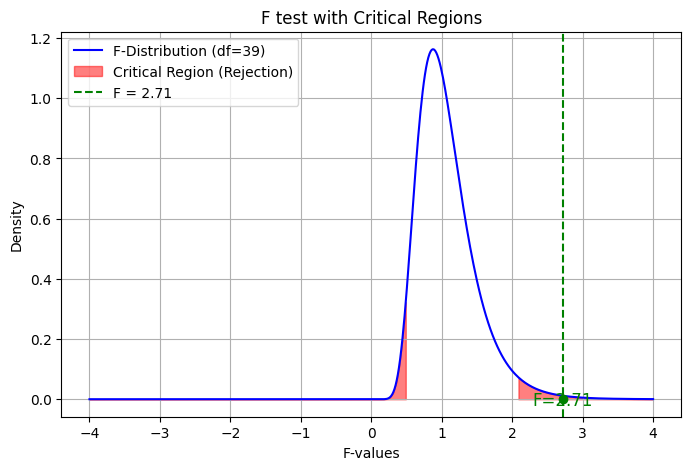

In [32]:
x = np.linspace(-4, 4, 500)
y = st.f.pdf(x, df_X, df_Y) 

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f'F-Distribution (df={df})', color='blue')

x_critical_right = np.linspace(critical_value2, 4, 100)
x_critical_left = np.linspace(-4, critical_value1, 100)

plt.fill_between(x_critical_right, st.f.pdf(x_critical_right, df_X, df_Y), color='red', alpha=0.5, label='Critical Region (Rejection)')
plt.fill_between(x_critical_left, st.f.pdf(x_critical_left, df_X, df_Y), color='red', alpha=0.5)

plt.axvline(F, color='green', linestyle='--', label=f'F = {round(F,2)}')

plt.scatter([F], [0], color='green', zorder=3)
plt.text(F, -0.02, f'F={round(F,2)}', color='green', fontsize=12, ha='center')

plt.title('F test with Critical Regions')
plt.xlabel('F-values')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()